# Periodic Solution Ensemble Benchmark

This notebook compares candidate solutions for the periodic branch, focusing on whether periodic baselines are subtracted accurately enough to recover one-off dimming events.

It uses the same hard synthetic population family as `periodic_branch_simulation_benchmark.ipynb`: multi-camera, seasonal, unevenly sampled, imperfectly periodic light curves with camera offsets, amplitude modulation, phase wander, slow trends, quasi-correlated residuals, and injected one-off dips.

The point of this notebook is not just whether the current branch detects events. It explicitly compares baseline solutions, period-error sensitivity, and a phase-local same-phase residual score that addresses the case where quiescent points overlap the event phase on other nights.

## Compared Solutions

The default comparison includes:

- `current_template_true_period`: current median phase-template branch with the true period.
- `current_template_1pct_period_error`: current template with selected-period scatter.
- `current_template_5pct_period_error`: selected-period stress test.
- `coarse_smooth_template`: fewer phase bins and stronger smoothing.
- `fine_template`: more phase bins and weaker smoothing.
- `leave_cycle_template`: phase template excluding points from the same cycle as the candidate point.
- `fourier_3harmonic`: harmonic-series periodic baseline.
- `ensemble_template_fourier`: median ensemble of current template, leave-cycle template, and Fourier baseline.
- `gp_masked_control`: current stochastic-branch baseline control.

Primary metrics to watch: `observable_recall`, `phase_local_observable_recall`, `control_false_positive_rate`, `off_target_detection_rate`, `median_resid_mad_outside_dip`, and `median_amp_recovery_ratio`.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/malca-matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from malca.evaluation.periodic_solution_ensemble_benchmark import (
    DEFAULT_SOLUTION_MODES,
    PeriodicSolutionBenchmarkConfig,
    load_periodic_solution_benchmark,
    plot_solution_baseline_mode_grid,
    plot_solution_heatmap,
    plot_solution_metrics,
    plot_solution_trial_diagnostic,
    run_periodic_solution_benchmark,
    select_baseline_gallery_trials,
    select_example_trials,
    write_solution_baseline_gallery,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

/home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Set `MALCA_PERIODIC_SOLUTION_SMOKE=1` for a quick execution check. The default notebook run is moderate, not production scale. Increase `MALCA_PERIODIC_SOLUTION_N_TRIALS` once the smoke run is clean.

In [2]:
SMOKE = os.getenv("MALCA_PERIODIC_SOLUTION_SMOKE", "0") == "1"
N_TRIALS = int(os.getenv("MALCA_PERIODIC_SOLUTION_N_TRIALS", "144" if SMOKE else "24000"))
WORKERS = int(os.getenv("MALCA_PERIODIC_SOLUTION_WORKERS", "1" if SMOKE else "8"))
FORCE = os.getenv("MALCA_PERIODIC_SOLUTION_FORCE", "0") == "1"
RUN_TAG = os.getenv("MALCA_PERIODIC_SOLUTION_RUN_TAG", "smoke" if SMOKE else None)

modes_text = os.getenv("MALCA_PERIODIC_SOLUTION_MODES", "")
MODE_NAMES = tuple(item.strip() for item in modes_text.split(",") if item.strip()) or DEFAULT_SOLUTION_MODES

config = PeriodicSolutionBenchmarkConfig(
    n_trials=N_TRIALS,
    workers=WORKERS,
    force=FORCE,
    run_tag=RUN_TAG,
    mode_names=MODE_NAMES,
    show_progress=True,
)
config

PeriodicSolutionBenchmarkConfig(output_base_dir=PosixPath('output/diagnostics/periodic_solution_ensemble_benchmark'), run_tag=None, n_trials=24000, seed=20260514, workers=8, show_progress=True, force=False, mode_names=('current_template_true_period', 'current_template_1pct_period_error', 'current_template_5pct_period_error', 'coarse_smooth_template', 'fine_template', 'leave_cycle_template', 'fourier_3harmonic', 'ensemble_template_fourier', 'gp_masked_control'), control_fraction=0.1, small_dip_fraction=0.5, medium_dip_fraction=0.32, broad_dip_fraction=0.08, trigger_mode='posterior_prob', logbf_threshold_dip=5.0, logbf_threshold_jump=5.0, significance_threshold=99.99997, p_points=12, mag_points=12, run_min_points=2, run_max_gap_points=5, run_max_gap_days=None, run_min_duration_days=0.0, compute_event_prob=True, baseline_s0=0.0005, baseline_w0=0.0031415926535897933, baseline_q=0.7, baseline_jitter=0.006, baseline_sigma_floor=None, phase_local_bins=64, phase_local_min_neighbors=6, phase_lo

## Run Or Load

This writes:

- `trial_design.parquet`
- `solution_results.parquet`
- `solution_results_with_design.parquet`
- `summary_tables/*.parquet`
- `summary_tables/*.csv`

In [3]:
run = run_periodic_solution_benchmark(config)
run.run_dir

Periodic solution benchmark:   6%|▋         | 13610/216000 [02:21<37:01, 91.09it/s] /home/calder/code/malca/malca/events.py:647: RuntimeWarning: All-NaN slice encountered
  baseline_guess = float(np.nanmedian(baseline[start_i:end_i]))
Periodic solution benchmark:  46%|████▌     | 98697/216000 [15:30<14:28, 135.08it/s]/home/calder/code/malca/malca/events.py:647: RuntimeWarning: All-NaN slice encountered
  baseline_guess = float(np.nanmedian(baseline[start_i:end_i]))
/home/calder/code/malca/malca/events.py:647: RuntimeWarning: All-NaN slice encountered
  baseline_guess = float(np.nanmedian(baseline[start_i:end_i]))
Periodic solution benchmark:  46%|████▌     | 98711/216000 [15:30<14:24, 135.71it/s]/home/calder/code/malca/malca/events.py:647: RuntimeWarning: All-NaN slice encountered
  baseline_guess = float(np.nanmedian(baseline[start_i:end_i]))
/home/calder/code/malca/malca/events.py:647: RuntimeWarning: All-NaN slice encountered
  baseline_guess = float(np.nanmedian(baseline[start_i:en

PosixPath('output/diagnostics/periodic_solution_ensemble_benchmark/20260514_144622')

## Overall Ranking

Read this first. A useful solution should improve recall without increasing off-target detections or false positives, and should preserve injected dip amplitude after baseline subtraction.

In [4]:
overall_cols = [
    "mode",
    "baseline_strategy",
    "n",
    "observable_recall",
    "phase_local_observable_recall",
    "precision_by_trial",
    "control_false_positive_rate",
    "off_target_detection_rate",
    "median_resid_mad_outside_dip",
    "median_amp_recovery_ratio",
    "median_phase_local_truth_peak_snr",
]

overall = run.summary_overall.loc[:, overall_cols].sort_values(
    ["observable_recall", "control_false_positive_rate", "off_target_detection_rate"],
    ascending=[False, True, True],
)
overall

,mode,baseline_strategy,n,observable_recall,phase_local_observable_recall,precision_by_trial,control_false_positive_rate,off_target_detection_rate,median_resid_mad_outside_dip,median_amp_recovery_ratio,median_phase_local_truth_peak_snr
7,gp_masked_control,gp_masked,22734,0.021998,0.000000,0.096632,0.155660,0.153122,0.198892,1.769912,NaN
8,leave_cycle_template,leave_cycle_template,23952,0.008348,0.386117,0.792683,0.002037,0.001349,0.064056,1.170148,3.459061
4,ensemble_template_fourier,ensemble,23968,0.006479,0.414908,0.770992,0.001630,0.001209,0.067156,1.160262,3.601637
5,fine_template,phase_template,23952,0.006292,0.412686,0.678082,0.002040,0.001953,0.067068,1.164755,3.649446
3,current_template_true_period,phase_template,23955,0.005970,0.418052,0.706767,0.002854,0.001488,0.068594,1.163749,3.618228
0,coarse_smooth_template,phase_template,23959,0.005006,0.421255,0.750000,0.001223,0.001069,0.071509,1.195825,3.594961
6,fourier_3harmonic,fourier,23980,0.003718,0.420742,0.734177,0.000815,0.000883,0.070488,1.169417,3.612329
1,current_template_1pct_period_error,phase_template,23983,0.002627,0.332586,0.494118,0.001222,0.001858,0.093733,1.266277,2.934987
2,current_template_5pct_period_error,phase_template,23989,0.001217,0.300602,0.344828,0.002038,0.001532,0.107247,1.289473,2.689490


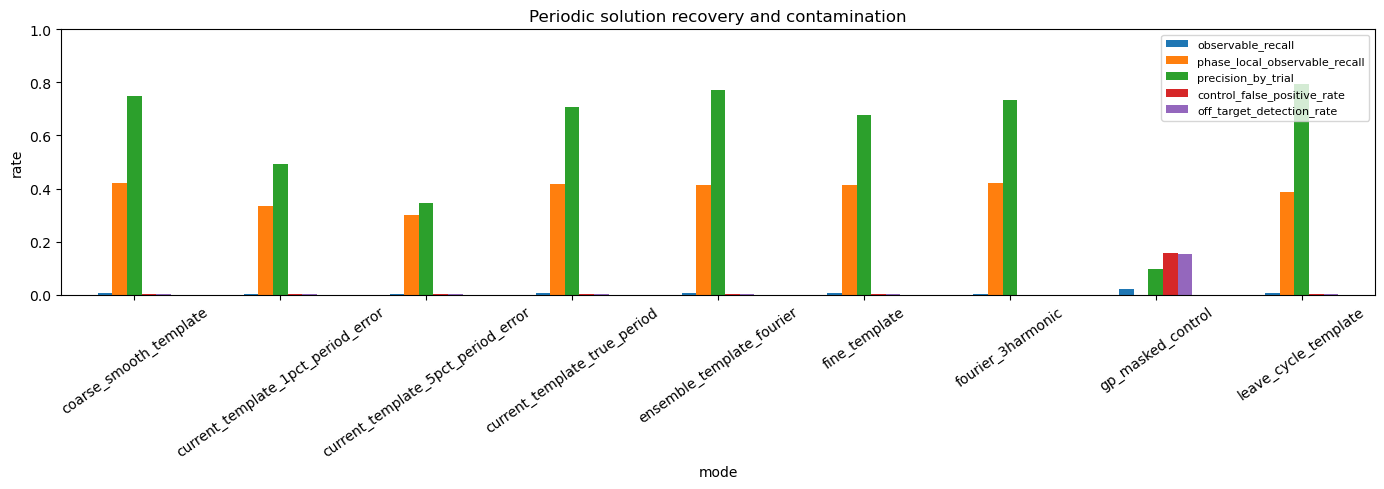

In [5]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
fig, ax = plt.subplots(figsize=figsize_from_legacy(14, 5))
plot_solution_metrics(run.summary_overall, ax=ax)
finalize_publication_figure(fig)


## Baseline Quality

This table isolates the baseline question from the event trigger question. Low outside-dip residual MAD/RMS and high amplitude recovery are what you want before tuning detection thresholds.

In [6]:
baseline_cols = [
    "mode",
    "median_baseline_mae_outside_dip",
    "median_baseline_rmse_outside_dip",
    "median_resid_rms_outside_dip",
    "median_resid_mad_outside_dip",
    "median_amp_recovery_ratio",
    "median_same_phase_truth_contrast_mag",
]
run.summary_overall.loc[:, baseline_cols].sort_values("median_resid_mad_outside_dip")

,mode,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_resid_mad_outside_dip,median_amp_recovery_ratio,median_same_phase_truth_contrast_mag
8,leave_cycle_template,0.036868,0.061958,0.076042,0.064056,1.170148,0.187260
5,fine_template,0.038666,0.061475,0.077001,0.067068,1.164755,0.183443
4,ensemble_template_fourier,0.035689,0.056867,0.073599,0.067156,1.160262,0.182570
3,current_template_true_period,0.038058,0.059947,0.076406,0.068594,1.163749,0.182160
6,fourier_3harmonic,0.036999,0.056838,0.074337,0.070488,1.169417,0.182546
0,coarse_smooth_template,0.038912,0.061044,0.077828,0.071509,1.195825,0.182289
1,current_template_1pct_period_error,0.057313,0.092007,0.103521,0.093733,1.266277,0.206427
2,current_template_5pct_period_error,0.067105,0.105794,0.115881,0.107247,1.289473,0.212270
7,gp_masked_control,0.144057,0.178126,0.184868,0.198892,1.769912,NaN


## Slice Tables

Use these to identify where a solution fails: small amplitude dips, sparse sampling, long periods, broad dips, or waveform morphology.

In [7]:
run.summary_slices["by_mode_and_amp"].sort_values(["mode", "dip_amp_bin"]).head(60)

,mode,dip_amp_bin,n,n_dip,n_observable_dip,n_control,dip_significant_rate,observable_recall,all_dip_recall,phase_local_observable_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_resid_mad_outside_dip,median_amp_recovery_ratio,median_phase_local_truth_peak_snr,median_same_phase_truth_contrast_mag
0,coarse_smooth_template,0.06-0.10,5965,5965,2958,0,0.001006,0.000000,0.000000,0.169371,NaN,0.001006,0.000000,0.038431,0.060362,0.077038,0.071213,1.369439,2.084540,0.112311
1,coarse_smooth_template,0.10-0.18,8327,8327,6340,0,0.001321,0.000315,0.000240,0.326341,NaN,0.001081,0.181818,0.038668,0.060721,0.077469,0.071122,1.244233,3.254253,0.163005
2,coarse_smooth_template,0.18-0.26,3974,3974,3487,0,0.006794,0.006309,0.005536,0.589905,NaN,0.001258,0.814815,0.039288,0.061696,0.078376,0.071974,1.149757,5.359264,0.255533
3,coarse_smooth_template,0.26+,3240,3240,2797,0,0.017593,0.019306,0.016667,0.692528,NaN,0.000926,0.947368,0.039627,0.061989,0.078637,0.071781,1.078702,6.717455,0.323842
4,coarse_smooth_template,control,2453,0,0,2453,0.001223,NaN,NaN,NaN,0.001223,NaN,0.000000,0.039674,0.061539,0.078747,0.072242,NaN,NaN,NaN
5,current_template_1pct_period_error,0.06-0.10,5967,5967,2960,0,0.002681,0.000000,0.000000,0.126014,NaN,0.002681,0.000000,0.056641,0.091953,0.103443,0.093534,1.485546,1.748851,0.126503
6,current_template_1pct_period_error,0.10-0.18,8327,8327,6340,0,0.001921,0.000315,0.000360,0.250631,NaN,0.001561,0.187500,0.056585,0.091135,0.102817,0.092656,1.309298,2.644160,0.179819
7,current_template_1pct_period_error,0.18-0.26,3977,3977,3490,0,0.005532,0.003725,0.003269,0.477650,NaN,0.002263,0.590909,0.058465,0.092842,0.104419,0.094578,1.226555,4.496025,0.282650
8,current_template_1pct_period_error,0.26+,3258,3258,2815,0,0.008594,0.009236,0.007980,0.554529,NaN,0.000614,0.928571,0.058407,0.093847,0.104723,0.094954,1.112258,5.351764,0.343498
9,current_template_1pct_period_error,control,2454,0,0,2454,0.001222,NaN,NaN,NaN,0.001222,NaN,0.000000,0.058223,0.091502,0.103663,0.094479,NaN,NaN,NaN


In [8]:
run.summary_slices["by_mode_and_period"].sort_values(["mode", "period_bin"]).head(80)

,mode,period_bin,n,n_dip,n_observable_dip,n_control,dip_significant_rate,observable_recall,all_dip_recall,phase_local_observable_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_resid_mad_outside_dip,median_amp_recovery_ratio,median_phase_local_truth_peak_snr,median_same_phase_truth_contrast_mag
0,coarse_smooth_template,10-25d,4884,4387,3201,497,0.003890,0.003749,0.002735,0.422368,0.000000,0.001596,0.631579,0.039318,0.061433,0.078027,0.071804,1.187685,3.556568,0.181386
1,coarse_smooth_template,2-5d,4620,4142,2945,478,0.003896,0.004414,0.003139,0.422071,0.002092,0.000966,0.722222,0.038967,0.061297,0.077896,0.071656,1.209321,3.538963,0.182010
2,coarse_smooth_template,25-50d,3631,3258,2390,373,0.004682,0.004603,0.003376,0.443933,0.000000,0.001842,0.647059,0.038529,0.060584,0.077402,0.070849,1.172874,3.693956,0.181673
3,coarse_smooth_template,5-10d,3563,3210,2303,353,0.005052,0.006947,0.004984,0.422492,0.002833,0.000312,0.888889,0.038566,0.060645,0.077464,0.071137,1.200572,3.672900,0.183118
4,coarse_smooth_template,50d+,2406,2133,1548,273,0.002078,0.001938,0.001406,0.405039,0.000000,0.000938,0.600000,0.039696,0.061585,0.078672,0.072172,1.157807,3.472669,0.180978
5,coarse_smooth_template,<2d,4855,4376,3195,479,0.005561,0.007199,0.005256,0.409390,0.002088,0.000686,0.851852,0.038838,0.060887,0.077597,0.071415,1.214653,3.674307,0.183959
6,current_template_1pct_period_error,10-25d,4888,4391,3205,497,0.004910,0.002496,0.001822,0.354446,0.000000,0.003644,0.333333,0.054504,0.088632,0.100969,0.090274,1.220959,3.064910,0.196966
7,current_template_1pct_period_error,2-5d,4624,4146,2949,478,0.002811,0.001356,0.000965,0.297728,0.002092,0.001930,0.307692,0.065656,0.104144,0.114362,0.104947,1.354204,2.807407,0.218893
8,current_template_1pct_period_error,25-50d,3632,3259,2392,373,0.003579,0.003763,0.002762,0.395067,0.000000,0.001227,0.692308,0.047427,0.076123,0.090348,0.080569,1.149770,3.288266,0.189530
9,current_template_1pct_period_error,5-10d,3572,3219,2312,353,0.004199,0.003893,0.002796,0.334775,0.002833,0.001553,0.600000,0.059743,0.097468,0.108708,0.097563,1.272030,2.945250,0.210272


## Recovery And Baseline Heatmaps

These show recall and amplitude preservation by dip amplitude and period. Start with the top-ranked modes from the overall table, then add more modes if needed.

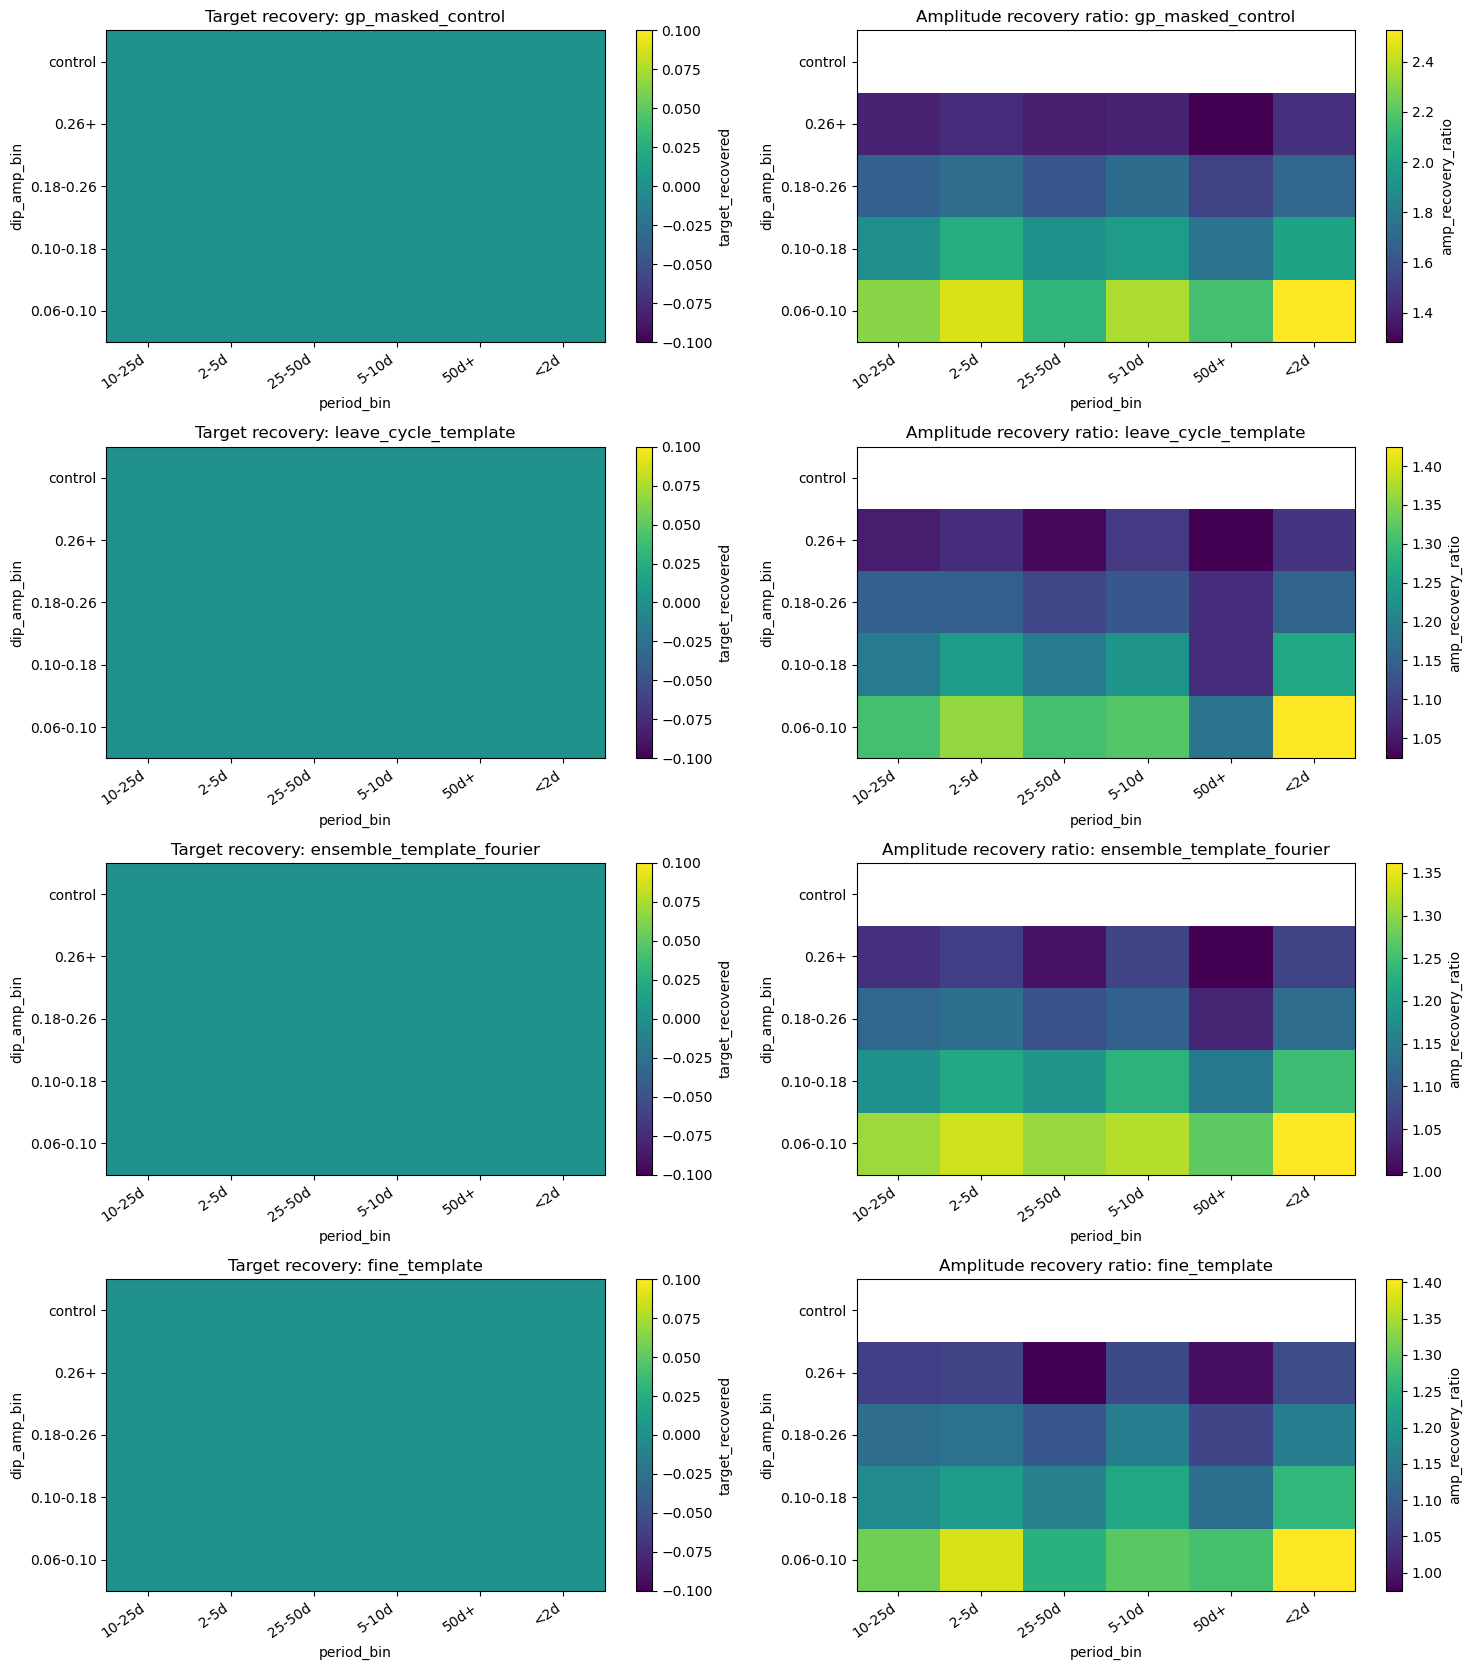

In [9]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
modes_to_plot = list(overall["mode"].head(4))
fig, axes = plt.subplots(len(modes_to_plot), 2, figsize=(15, 4.2 * len(modes_to_plot)))
axes = np.atleast_2d(axes)
for row_idx, mode in enumerate(modes_to_plot):
    plot_solution_heatmap(
        run.solution_results,
        metric="target_recovered",
        mode=mode,
        ax=axes[row_idx, 0],
        title=f"Target recovery: {mode}",
    )
    plot_solution_heatmap(
        run.solution_results,
        metric="amp_recovery_ratio",
        mode=mode,
        ax=axes[row_idx, 1],
        title=f"Amplitude recovery ratio: {mode}",
    )
finalize_publication_figure(fig)


## Failure Tables

`phase_local_only` rows are especially important: those are cases where the same-phase residual contrast is present but the current Bayesian/run path did not recover the injected dip.

In [10]:
best_mode = str(overall.iloc[0]["mode"])
current_mode = "current_template_true_period" if "current_template_true_period" in set(run.solution_results["mode"]) else best_mode

cols = [
    "trial_id",
    "mode",
    "dip_class",
    "period_days",
    "n_points_actual",
    "dip_amp_mag",
    "dip_sigma_days",
    "truth_peak_snr_actual",
    "target_recovered",
    "phase_local_detected",
    "phase_local_truth_peak_snr",
    "same_phase_truth_contrast_mag",
    "amp_recovery_ratio",
    "baseline_source",
]

misses = run.solution_results[
    run.solution_results["mode"].eq(current_mode)
    & run.solution_results["has_dip"].fillna(False).astype(bool)
    & run.solution_results["truth_observable_actual"].fillna(False).astype(bool)
    & ~run.solution_results["target_recovered"].fillna(False).astype(bool)
].copy()

misses.loc[:, cols].sort_values("phase_local_truth_peak_snr", ascending=False).head(25)

/tmp/ipykernel_3940736/1813502038.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & run.solution_results["truth_observable_actual"].fillna(False).astype(bool)
/tmp/ipykernel_3940736/1813502038.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~run.solution_results["target_recovered"].fillna(False).astype(bool)


,trial_id,mode,dip_class,period_days,n_points_actual,dip_amp_mag,dip_sigma_days,truth_peak_snr_actual,target_recovered,phase_local_detected,phase_local_truth_peak_snr,same_phase_truth_contrast_mag,amp_recovery_ratio,baseline_source
141940,15771,current_template_true_period,broad,21.610792,614.0,0.271515,4.784997,11.532610,False,True,185.741701,0.334951,1.097443,phase_template
86374,9597,current_template_true_period,medium,13.287991,577.0,0.305625,0.624050,13.127921,False,True,106.462974,0.473148,1.339055,phase_template
70135,7793,current_template_true_period,medium,13.012112,219.0,0.237640,3.338952,4.468087,False,True,98.999137,0.441739,1.668085,phase_template
40884,4543,current_template_true_period,medium,62.666694,231.0,0.255129,4.177716,12.328503,False,True,90.108375,0.359946,0.998373,phase_template
42758,4751,current_template_true_period,broad,74.841523,473.0,0.206066,13.364449,8.961593,False,True,85.941182,0.339519,1.460687,phase_template
209357,23262,current_template_true_period,broad,1.956716,195.0,0.230611,11.579742,15.327373,False,False,79.537481,0.252659,1.183808,phase_template
175797,19533,current_template_true_period,medium,2.260932,429.0,0.158199,3.073590,4.255405,False,True,76.122087,0.202781,1.132198,phase_template
148571,16508,current_template_true_period,medium,17.428282,476.0,0.266690,1.386823,25.401859,False,True,72.915562,0.339155,0.835051,phase_template
84771,9419,current_template_true_period,medium,39.375991,420.0,0.258799,4.474620,7.823766,False,True,70.557531,0.445773,1.394706,phase_template
29868,3319,current_template_true_period,medium,7.841955,192.0,0.215315,0.763039,7.770064,False,True,65.719264,0.182306,0.739343,phase_template


In [11]:
phase_local_only = misses[misses["phase_local_detected"].fillna(False).astype(bool)].copy()
phase_local_only.loc[:, cols].sort_values("phase_local_truth_peak_snr", ascending=False).head(25)

/tmp/ipykernel_3940736/3426622781.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phase_local_only = misses[misses["phase_local_detected"].fillna(False).astype(bool)].copy()


,trial_id,mode,dip_class,period_days,n_points_actual,dip_amp_mag,dip_sigma_days,truth_peak_snr_actual,target_recovered,phase_local_detected,phase_local_truth_peak_snr,same_phase_truth_contrast_mag,amp_recovery_ratio,baseline_source
141940,15771,current_template_true_period,broad,21.610792,614.0,0.271515,4.784997,11.532610,False,True,185.741701,0.334951,1.097443,phase_template
86374,9597,current_template_true_period,medium,13.287991,577.0,0.305625,0.624050,13.127921,False,True,106.462974,0.473148,1.339055,phase_template
70135,7793,current_template_true_period,medium,13.012112,219.0,0.237640,3.338952,4.468087,False,True,98.999137,0.441739,1.668085,phase_template
40884,4543,current_template_true_period,medium,62.666694,231.0,0.255129,4.177716,12.328503,False,True,90.108375,0.359946,0.998373,phase_template
42758,4751,current_template_true_period,broad,74.841523,473.0,0.206066,13.364449,8.961593,False,True,85.941182,0.339519,1.460687,phase_template
175797,19533,current_template_true_period,medium,2.260932,429.0,0.158199,3.073590,4.255405,False,True,76.122087,0.202781,1.132198,phase_template
148571,16508,current_template_true_period,medium,17.428282,476.0,0.266690,1.386823,25.401859,False,True,72.915562,0.339155,0.835051,phase_template
84771,9419,current_template_true_period,medium,39.375991,420.0,0.258799,4.474620,7.823766,False,True,70.557531,0.445773,1.394706,phase_template
29868,3319,current_template_true_period,medium,7.841955,192.0,0.215315,0.763039,7.770064,False,True,65.719264,0.182306,0.739343,phase_template
195263,21696,current_template_true_period,medium,21.090854,249.0,0.315830,2.580709,9.063149,False,True,64.954757,0.449070,1.434311,phase_template


In [12]:
false_positives = run.solution_results[
    run.solution_results["mode"].eq(best_mode)
    & run.solution_results["false_positive"].fillna(False).astype(bool)
].copy()

false_positives.loc[:, cols].sort_values("dip_bayes_factor", ascending=False).head(25)

/tmp/ipykernel_3940736/545815357.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & run.solution_results["false_positive"].fillna(False).astype(bool)


KeyError: 'dip_bayes_factor'

## Example Diagnostics

Pick a mode and inspect representative successes, misses, off-target detections, false positives, and phase-local-only cases.

In [ ]:
EXAMPLE_MODE = best_mode
examples = select_example_trials(run.solution_results, EXAMPLE_MODE)
examples

In [ ]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
for label, trial_id in examples.items():
    if trial_id is None:
        continue
    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)
    plot_solution_trial_diagnostic(run, int(trial_id), mode=EXAMPLE_MODE, ax=axes)
    fig.suptitle(f"{label}: trial {trial_id} | {EXAMPLE_MODE}", y=1.0)
    finalize_publication_figure(fig)


## Baseline Mode Gallery

Render a larger set of per-trial baseline comparison figures. Each saved PNG has one row per baseline mode: observed light curve plus fitted baseline on the left, and the baseline-subtracted residual light curve on the right.

In [ ]:
BASELINE_GALLERY_N = int(os.getenv("MALCA_PERIODIC_SOLUTION_BASELINE_GALLERY_N", "16" if SMOKE else "36"))
BASELINE_GALLERY_MODES = MODE_NAMES

baseline_gallery_trial_ids = select_baseline_gallery_trials(
    run.solution_results,
    reference_mode=EXAMPLE_MODE,
    n_trials=BASELINE_GALLERY_N,
    seed=config.seed,
)
baseline_gallery_trial_ids[:12], len(baseline_gallery_trial_ids)

In [ ]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
if baseline_gallery_trial_ids:
    fig, axes = plt.subplots(len(BASELINE_GALLERY_MODES), 2, figsize=(16, max(3.0 * len(BASELINE_GALLERY_MODES), 5.5)), sharex="col", squeeze=False)
    plot_solution_baseline_mode_grid(run, int(baseline_gallery_trial_ids[0]), modes=BASELINE_GALLERY_MODES, ax=axes)
    fig.suptitle(f"Preview baseline-mode gallery: trial {baseline_gallery_trial_ids[0]}", y=0.995)
    finalize_publication_figure(fig)


In [ ]:
baseline_gallery_paths = write_solution_baseline_gallery(
    run,
    trial_ids=baseline_gallery_trial_ids,
    modes=BASELINE_GALLERY_MODES,
    output_dir=run.run_dir / "plots" / "baseline_mode_gallery",
    show_progress=True,
)
baseline_gallery_paths[:5], len(baseline_gallery_paths)

## Interpretation Checklist

- If `current_template_true_period` has weak recall, the current periodic branch is baseline or scorer limited even with perfect period selection.
- If true-period recall is good but 1%/5% period-error modes collapse, period selection quality is the bottleneck.
- If `leave_cycle_template` or `ensemble_template_fourier` improves `median_amp_recovery_ratio`, the current template is absorbing part of one-off dips.
- If `phase_local_observable_recall` is much higher than `observable_recall`, the baseline contains the event information but the stochastic event scorer/run filters are suppressing it.
- If false positives rise in Fourier or fine-template modes, the model is likely leaving structured phase residuals or overfitting sparse phase regions.
- If GP control wins on periodic curves, the folding assumptions are too brittle for the simulated cadence/period regime and the pregate needs stricter period-quality requirements.